# День 08. Упражнение 03
# Переобучение

## 0. Импорты

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import GridSearchCV
from sklearn.multiclass import OneVsRestClassifier

## 1. Предобработка

1. Прочитай файл `dayofweek.csv` в DataFrame.
2. Используя `train_test_split` с параметрами `test_size=0.2`, `random_state=21`, получи `X_train`, `y_train`, `X_test`, `y_test`.
3. С помощью, например, `value_counts()` проверь, похожее ли распределение классов в train и test.
4. Добавь параметр `stratify=` и проверь распределение снова — теперь оно должно быть более-менее одинаковым в обоих наборах данных.

In [2]:
df = pd.read_csv('../data/dayofweek.csv')
df.head()

,dayOfWeek,hour,numTrials,uid_user_0,uid_user_1,uid_user_10,uid_user_11,uid_user_12,uid_user_13,uid_user_14,...,labname_lab02,labname_lab03,labname_lab03s,labname_lab05s,labname_laba04,labname_laba04s,labname_laba05,labname_laba06,labname_laba06s,labname_project1
0,4,-2.562352,-0.788667,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
1,4,-2.562352,-0.756764,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
2,4,-2.562352,-0.724861,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
3,4,-2.562352,-0.692958,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
4,4,-2.562352,-0.661055,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0


In [3]:
X = df.drop('dayOfWeek', axis=1)
y = df['dayOfWeek']

In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=21
)

In [5]:
y_train.value_counts()

dayOfWeek
3    313
6    287
1    222
5    216
2    125
0    105
4     80
Name: count, dtype: int64

In [6]:
y_test.value_counts()

dayOfWeek
3    83
6    69
5    55
1    52
0    31
4    24
2    24
Name: count, dtype: int64

In [7]:
df_counts = pd.concat([y_train.value_counts(), y_test.value_counts()], axis=1)
df_counts.columns = ['train', 'test']
df_counts.index.name = 'dayofweek'
df_counts['p_train']=(df_counts['train']*100)/(df_counts['train']+df_counts['test'])
df_counts['p_test']=100-df_counts['p_train']
df_counts

,train,test,p_train,p_test
dayofweek,,,,
3,313,83,79.040404,20.959596
6,287,69,80.617978,19.382022
1,222,52,81.021898,18.978102
5,216,55,79.704797,20.295203
2,125,24,83.892617,16.107383
0,105,31,77.205882,22.794118
4,80,24,76.923077,23.076923


In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=21,
    stratify=y
)

In [9]:
y_train.value_counts()

dayOfWeek
3    316
6    285
1    219
5    217
2    119
0    109
4     83
Name: count, dtype: int64

In [10]:
y_test.value_counts()

dayOfWeek
3    80
6    71
1    55
5    54
2    30
0    27
4    21
Name: count, dtype: int64

In [11]:
df_counts = pd.concat([y_train.value_counts(), y_test.value_counts()], axis=1)
df_counts.columns = ['train', 'test']
df_counts.index.name = 'dayofweek'
df_counts['p_train']=(df_counts['train']*100)/(df_counts['train']+df_counts['test'])
df_counts['p_test']=100-df_counts['p_train']
df_counts

,train,test,p_train,p_test
dayofweek,,,,
3,316,80,79.797980,20.202020
6,285,71,80.056180,19.943820
1,219,55,79.927007,20.072993
5,217,54,80.073801,19.926199
2,119,30,79.865772,20.134228
0,109,27,80.147059,19.852941
4,83,21,79.807692,20.192308


## 2. Базовые модели

1. Обучи те же самые базовые модели из предыдущего упражнения и вычисли accuracy, используя тестовый набор данных со стратификацией.
2. Все ли модели показали похожие значения метрики? Какая из них показала наибольшее отличие по сравнению с предыдущим упражнением? Напиши ответ в markdown-ячейке в конце раздела.

### a. Логистическая регрессия

In [12]:
logist = LogisticRegression(random_state=21, fit_intercept=False)
logist.fit(X_train, y_train)
y_pred = logist.predict(X_test)
accuracy_score(y_test, y_pred)

0.6331360946745562

### b. SVM

In [13]:
svm_ovr = OneVsRestClassifier(SVC(kernel='linear', probability=True, random_state=21))
svm_ovr.fit(X_train, y_train)
y_pred_ovr = svm_ovr.predict(X_test)
accuracy_score(y_test, y_pred_ovr)

0.6183431952662722

### c. Дерево решений

In [14]:
tree = DecisionTreeClassifier(random_state=21, max_depth=4)
tree.fit(X_train, y_train)
y_pred = tree.predict(X_test)
accuracy_score(y_test, y_pred)

0.5295857988165681

### d. Случайный лес

In [16]:
forest = RandomForestClassifier(random_state=21, max_depth=25, n_estimators=100)
forest.fit(X_train, y_train)
y_pred = forest.predict(X_test)
accuracy_score(y_test, y_pred)

0.9289940828402367

random forest

## 3. Кросс-валидация

Можно было бы “поиграть” с параметрами модели, чтобы добиться более высокой точности на тестовом наборе, но так делать не принято. Такая тактика снова приводит к переобучению. Тестовый набор предназначен только для финальной проверки качества модели.

Однако есть другой способ решения этой задачи — кросс-валидация. Он не использует тестовый набор, а создает дополнительное разбиение обучающего набора. Существует несколько способов реализации, но общая идея одна: появляется валидационный набор, который используется для подбора гиперпараметров.

1. Используя `cross_val_score` с параметром `cv=10`, вычисли среднее значение accuracy и стандартное отклонение для каждой модели, использованной ранее (логистическая регрессия с `solver='liblinear'`, SVC, дерево решений, случайный лес).

### a. Логистическая регрессия

In [17]:
scores = cross_val_score(logist, X_train, y_train, cv=10)
print(f'mean={scores.mean()}, standartd deviantion={scores.std()}')

mean=0.6023880597014925, standartd deviantion=0.02852354077568261


### b. SVM

In [18]:
scores = cross_val_score(svm_ovr, X_train, y_train, cv=10)
print(f'mean={scores.mean()}, standartd deviantion={scores.std()}')

mean=0.5705085682697624, standartd deviantion=0.037010421284044116


### c. Дерево решений

In [19]:
scores = cross_val_score(tree, X_train, y_train, cv=10)
print(f'mean={scores.mean()}, standartd deviantion={scores.std()}')

mean=0.5088944168048645, standartd deviantion=0.031903139495514356


### d. Случайный лес

In [20]:
scores = cross_val_score(forest, X_train, y_train, cv=10)
print(f'mean={scores.mean()}, standartd deviantion={scores.std()}')

mean=0.9124543946932006, standartd deviantion=0.014043344960921304


## 4. Оптимизация

1. Выбери лучшую модель и немного поиграй с её параметрами на кросс-валидации, чтобы найти достаточно хорошие параметры или их комбинацию.
2. Вычисли accuracy для финальной модели на тестовом наборе данных.
3. Построй график, отображающий 10 самых важных признаков для этой модели.
4. Сохрани модель с помощью `joblib`.
5. Загрузи модель, сделай предсказания для тестового набора и вычисли accuracy.

In [21]:
def plot_top_features(coef_matrix, feature_names, top_n=10):
          
    if coef_matrix.ndim == 1:
        importance = np.abs(coef_matrix)
    else:
        importance = np.sum(np.abs(coef_matrix), axis=0)
    top_idx = np.argsort(importance)[-top_n:]

    plt.figure(figsize=(10, 6))
    plt.barh(np.array(feature_names)[top_idx], importance[top_idx])
    plt.xlabel('Суммарная важность признака (по всем классам)')
    plt.title(f'Top {top_n} most important features')
    plt.grid(True)
    plt.tight_layout()
    plt.show()

In [22]:
param_grid = {
    'n_estimators': [50, 100, 150],
    'max_depth': [10, 15, 20, 25, None]
}

In [24]:
rf = RandomForestClassifier(random_state=21)
grid_search = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    cv=5,               
    n_jobs=-1,         
    verbose=2
)
grid_search.fit(X_train, y_train)

Fitting 5 folds for each of 15 candidates, totalling 75 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestC...ndom_state=21)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'max_depth': [10, 15, ...], 'n_estimators': [50, 100, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",None
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : the score is also displayed;- >3

In [26]:
print("Лучшие параметры:", grid_search.best_params_)
print("Лучшая средняя точность (cv):", grid_search.best_score_)

Лучшие параметры: {'max_depth': None, 'n_estimators': 150}
Лучшая средняя точность (cv): 0.9005920418559823


In [27]:
final_model = grid_search.best_estimator_
y_pred = final_model.predict(X_test)
accuracy_score(y_test, y_pred)

0.9349112426035503

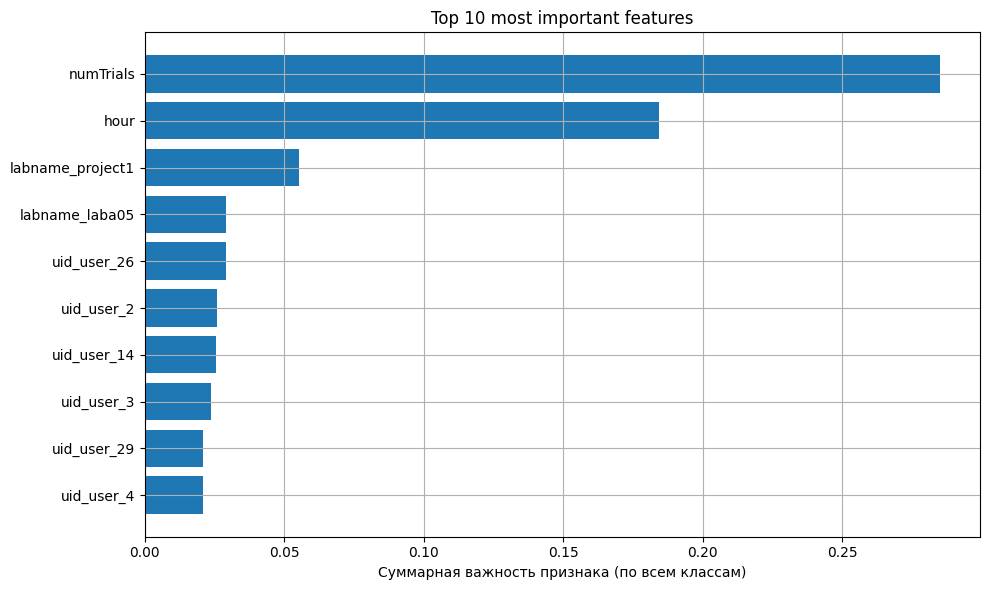

In [28]:
plot_top_features(final_model.feature_importances_,X.columns)

In [29]:
joblib.dump(final_model, 'best_model.pkl')

['best_model.pkl']

In [30]:
loaded_model = joblib.load('best_model.pkl')

In [31]:
y_pred_loaded = loaded_model.predict(X_test)

In [31]:
loaded_accuracy = accuracy_score(y_test, y_pred_loaded)
print(f'Accuracy загруженной модели: {loaded_accuracy}')

Accuracy загруженной модели: 0.9349112426035503
